In [50]:
import pandas as pd
import numpy as np
import os

#visuals
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")



In [51]:
#file paths
exo_planets_path = "../data/nasa_exoplanets.csv"
koi_path = "../data/koi.csv"

#Planets in the Solar System  CSV (DataHerb / GitHub)
url = "https://raw.githubusercontent.com/InterImm/dataset-planets-in-solar-system/master/dataset/planets_in_solar_system.csv"
solar_df = pd.read_csv(url)

exo_planets_df = pd.read_csv(exo_planets_path,sep=',')
koi_df = pd.read_csv(koi_path)

In [52]:
exo_planets_df.columns

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [53]:
# to many columns some can be removed
exo_columns = ['pl_name', 'hostname', 'discoverymethod', 'disc_year',
    'pl_orbper', 'pl_orbsmax', 'pl_orbeccen',
    'pl_rade', 'pl_bmasse', 'pl_eqt','pl_insol',
    'st_teff', 'st_rad', 'st_mass', 'st_met',
    'sy_dist']
exo_planets_clean = exo_planets_df[exo_columns]
exo_planets_clean.head()
exo_planets_clean.to_csv("exo_planets_clean.csv", index=False)

In [54]:
#repeat for koi
koi_df.columns


Index(['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')

In [55]:
koi_df = koi_df[koi_df["koi_disposition"].isin(["CONFIRMED", "CANDIDATE"])]
# Add a label column for confirmation status
koi_df["confirmation_status"] = koi_df["koi_disposition"]

# Select and rename so columns match other dataset
koi_clean = koi_df[[
    "kepler_name", "koi_period", "koi_prad", "koi_teq",
    "koi_insol", "koi_steff", "koi_slogg", "koi_srad",
    "koi_kepmag", "ra", "dec", "confirmation_status"
]].rename(columns={
    "kepler_name": "pl_name",
    "koi_period": "pl_orbper",
    "koi_prad": "pl_rade",
    "koi_teq": "pl_eqt",
    "koi_insol": "pl_insol",
    "koi_steff": "st_teff",
    "koi_slogg": "st_logg",
    "koi_srad": "st_rad",
    "koi_kepmag": "sy_vmag"
})
koi_clean.to_csv("koi_clean.csv", index=False)

In [56]:
solar_df.columns

Index(['name', 'equatorial_diameter', 'mass', 'semi_major_axis',
       'orbital_period', 'inclination_to_suns_equator', 'orbital_eccentricity',
       'rotation_period', 'confirmed_moons', 'axial_tilt', 'rings',
       'atmosphere'],
      dtype='object')

In [57]:
solar_df.head()

,name,equatorial_diameter,mass,semi_major_axis,orbital_period,inclination_to_suns_equator,orbital_eccentricity,rotation_period,confirmed_moons,axial_tilt,rings,atmosphere
0,Mercury,0.382,0.06,0.39,0.24,3.38,0.206,58.64,0,0.04,no,minimal
1,Venus,0.949,0.82,0.72,0.62,3.86,0.007,−243.02,0,177.36,no,"CO2, N2"
2,Earth,1.000,1.00,1.00,1.00,7.25,0.017,1,1,23.44,no,"N2, O2, Ar"
3,Mars,0.532,0.11,1.52,1.88,5.65,0.093,1.03,2,25.19,no,"CO2, N2, Ar"
4,Jupiter,11.209,317.80,5.20,11.86,6.09,0.048,0.41,79,3.13,yes,"H2, He"


In [58]:
solar_df["pl_rade"] = solar_df["equatorial_diameter"] / 2 / 6371  # Convert diameter → radius in Earth units
solar_df["pl_bmasse"] = solar_df["mass"] / (5.972e24)  # kg to Earth masses
solar_df['pl_eqt'] = [449 , 328 , 279 , 226 , 122 , 90 , 64 , 51] # add equilibrium temperature

# Add Solar values for stellar info
solar_df["st_teff"] = 5778
solar_df["st_rad"] = 1.0
solar_df["st_mass"] = 1.0
solar_df["st_met"] = 0.0122


# Rename for consistency with exoplanet datasets
solar_clean = solar_df.rename(columns={
    "name": "pl_name",
    "semi_major_axis": "pl_orbsmax",
    "orbital_period": "pl_orbper",
    "orbital_eccentricity": "pl_orbeccen"
})

# Select only the aligned columns
columns_to_keep = [
    "pl_name", "pl_orbper", "pl_orbsmax", "pl_orbeccen",
    "pl_rade", "pl_bmasse", "st_teff", "st_rad", "st_mass", "st_met","pl_eqt"
]
solar_clean = solar_clean[columns_to_keep]
solar_clean['pl_insol'] = 1 / (solar_clean['pl_orbsmax'] ** 2)
solar_clean.to_csv("solar_clean.csv", index=False)

In [59]:
# Basic EDA exoplanet

# Set options to display full output
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
# --- 1. Shape & Columns ---
print("Shape:", exo_planets_clean.shape)
print("Columns:", exo_planets_clean.columns.tolist())


# --- 2. Missing Values ---
print("\nMissing values:\n", exo_planets_clean.isnull().sum())

# --- 3. Data Types ---
print("\nData types:\n", exo_planets_clean.dtypes)

# --- 4. Descriptive Stats ---
print("\nDescriptive stats:\n", exo_planets_clean.describe())

#-- 5. General questions ---
#most common discovery method
print(exo_planets_clean["discoverymethod"].value_counts().head(3))
#most popular discovery year
print(exo_planets_clean["disc_year"].value_counts().head(3))

Shape: (38509, 16)
Columns: ['pl_name', 'hostname', 'discoverymethod', 'disc_year', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_rade', 'pl_bmasse', 'pl_eqt', 'pl_insol', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'sy_dist']

Missing values:
 pl_name                0
hostname               0
discoverymethod        0
disc_year              0
pl_orbper           3211
pl_orbsmax         16824
pl_orbeccen        20010
pl_rade            11955
pl_bmasse          31834
pl_eqt             21682
pl_insol           21675
st_teff             3218
st_rad              2982
st_mass             5822
st_met             14038
sy_dist              840
dtype: int64

Data types:
 pl_name             object
hostname            object
discoverymethod     object
disc_year            int64
pl_orbper          float64
pl_orbsmax         float64
pl_orbeccen        float64
pl_rade            float64
pl_bmasse          float64
pl_eqt             float64
pl_insol           float64
st_teff            float64
st_rad

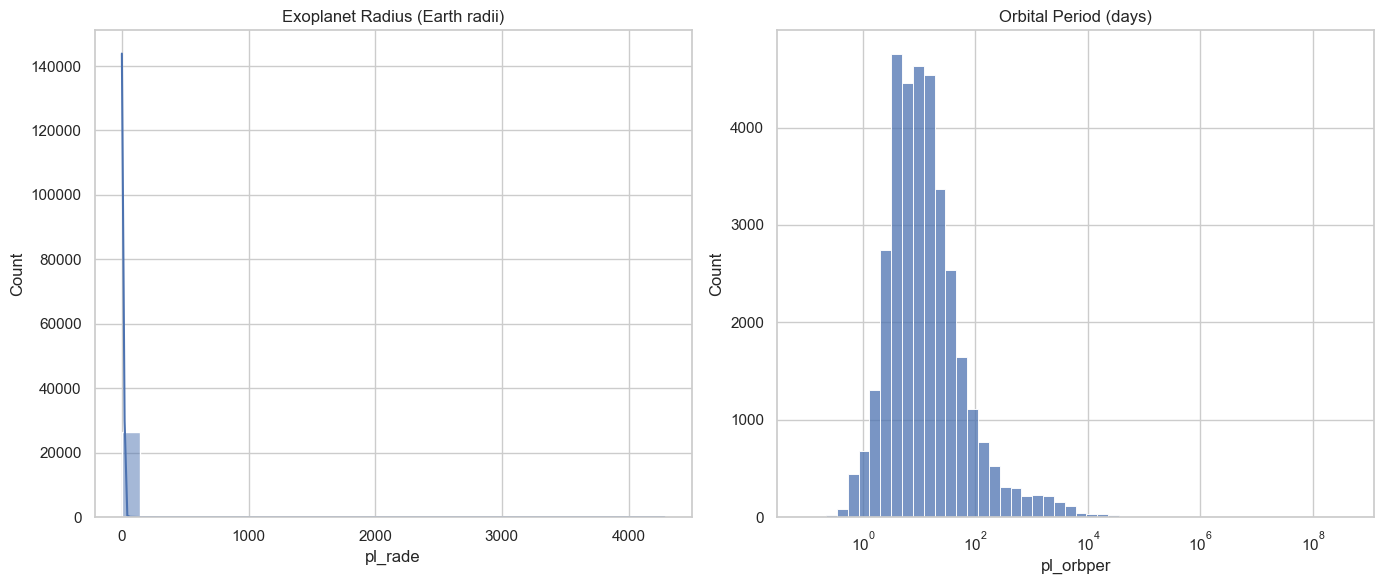

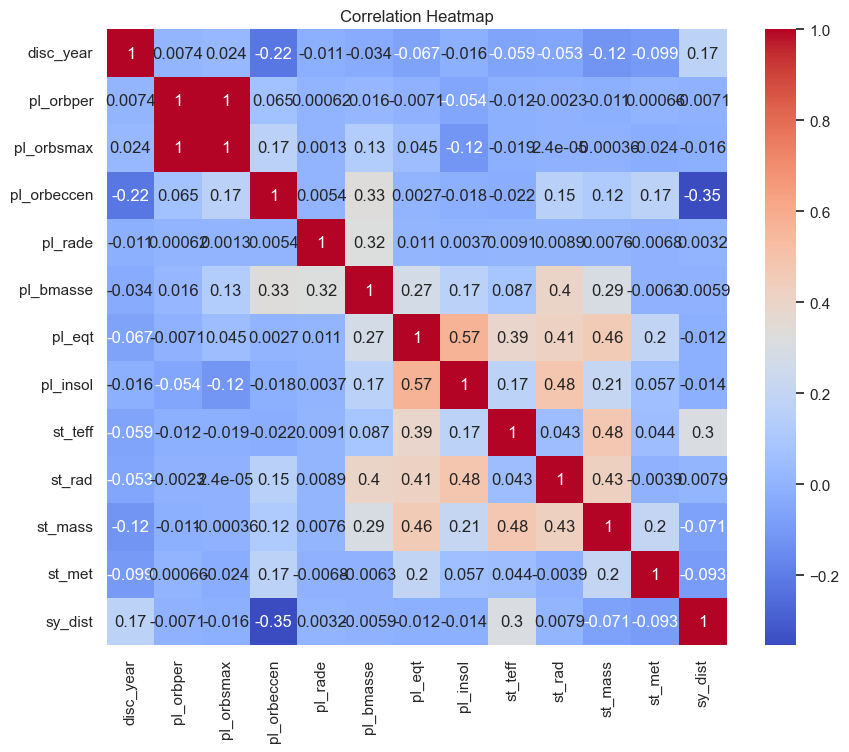

In [60]:
#plots
exo_planets_clean.columns
# --- 5. Distribution Plots ---
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(exo_planets_clean["pl_rade"].dropna(), bins=30, kde=True)
plt.title("Exoplanet Radius (Earth radii)")

plt.subplot(1, 2, 2)
sns.histplot(exo_planets_clean["pl_orbper"].dropna(), bins=50, log_scale=True)
plt.title("Orbital Period (days)")
plt.tight_layout()
plt.show()

# --- 6. Correlation Matrix ---
plt.figure(figsize=(10, 8))
sns.heatmap(exo_planets_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Planet Size & Mass Relationship: Validates physical models — bigger radius → more mass

Star Properties Are Interconnected: Stellar mass, temperature, and radius go hand-in-hand

Eccentricity Trends Over Time: Older detections are more eccentric — maybe due to biases in radial velocity methods

Equilibrium Temp Tied to Star: Bigger, hotter stars make hotter planets — this might be useful when exploring potential habitability

Distance Doesn't Correlate Much: No surprise — detection distance is more about telescope sensitivity

Shape: (4725, 12)
Columns: ['pl_name', 'pl_orbper', 'pl_rade', 'pl_eqt', 'pl_insol', 'st_teff', 'st_logg', 'st_rad', 'sy_vmag', 'ra', 'dec', 'confirmation_status']

Missing values:
 pl_name                1980
pl_orbper                 0
pl_rade                 106
pl_eqt                  106
pl_insol                103
st_teff                 106
st_logg                 106
st_rad                  106
sy_vmag                   0
ra                        0
dec                       0
confirmation_status       0
dtype: int64

Data types:
 pl_name                 object
pl_orbper              float64
pl_rade                float64
pl_eqt                 float64
pl_insol               float64
st_teff                float64
st_logg                float64
st_rad                 float64
sy_vmag                float64
ra                     float64
dec                    float64
confirmation_status     object
dtype: object

Descriptive stats:
            pl_orbper        pl_rade       pl_eqt

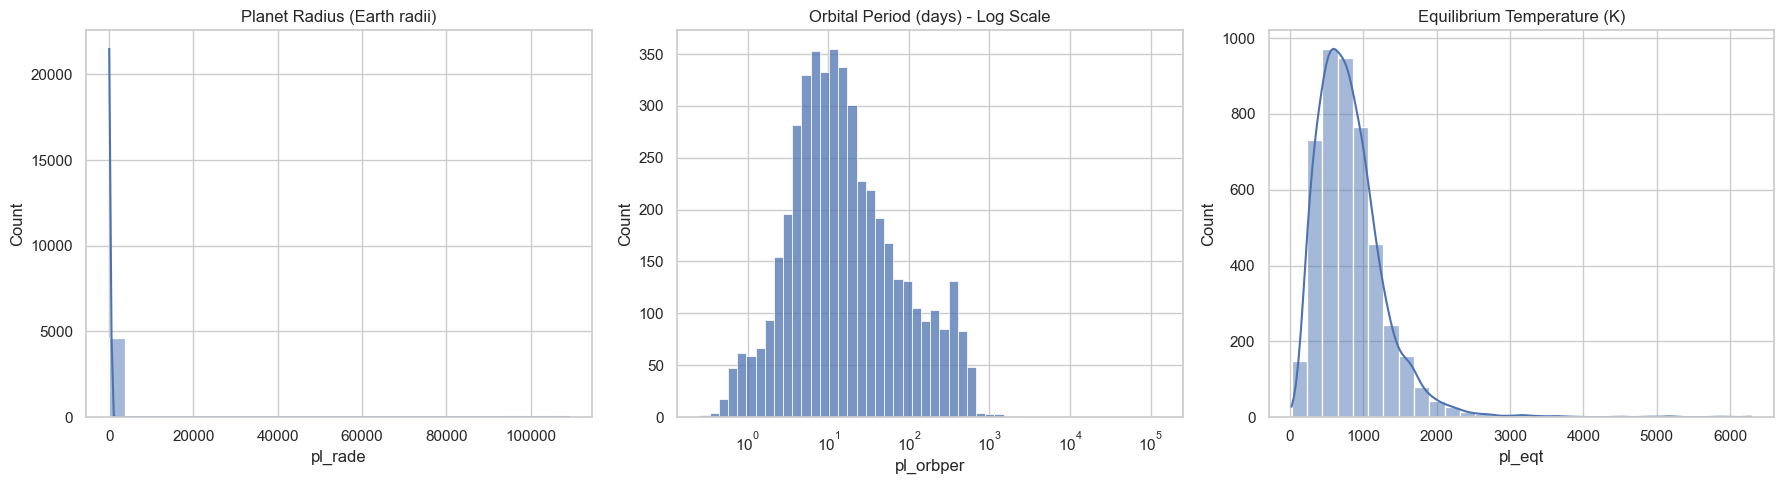

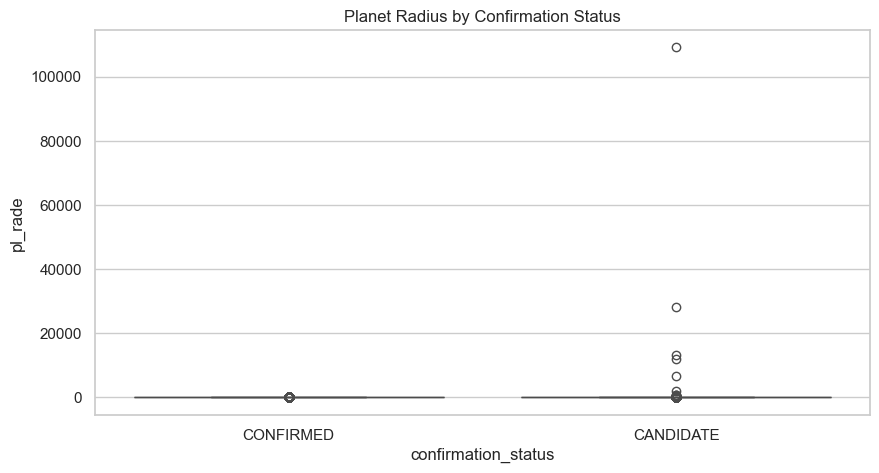

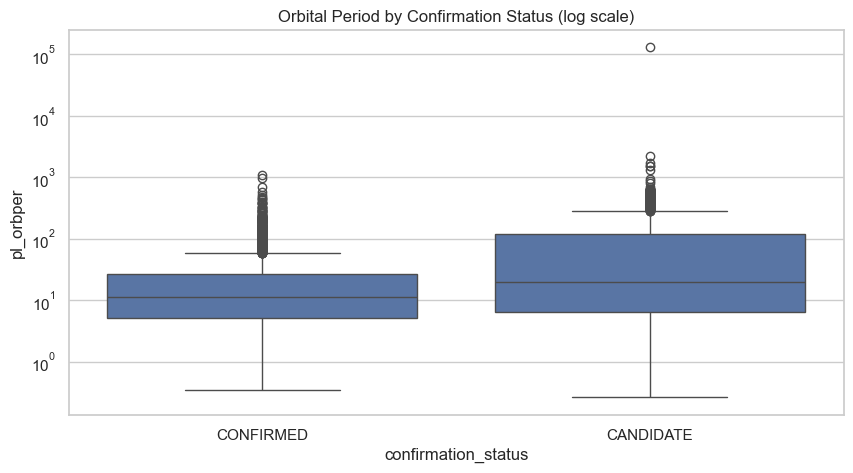

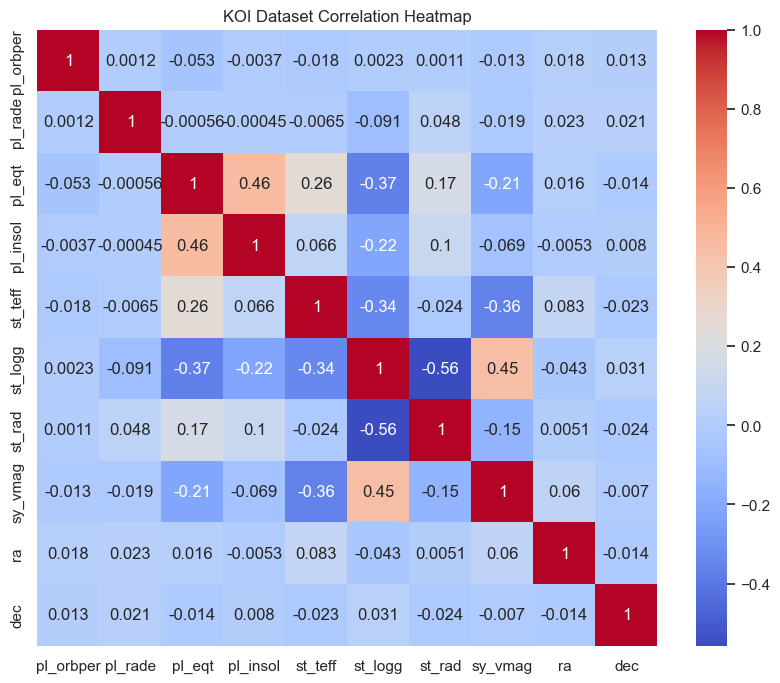

In [61]:
#Basic EDA KOI


# Set options to display full output
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
# --- 1. Shape & Columns ---
print("Shape:", koi_clean.shape)
print("Columns:", koi_clean.columns.tolist())


# --- 2. Missing Values ---
print("\nMissing values:\n", koi_clean.isnull().sum())

# --- 3. Data Types ---
print("\nData types:\n", koi_clean.dtypes)

# --- 4. Descriptive Stats ---
print("\nDescriptive stats:\n", koi_clean.describe())



# --- 4. Plot Distributions ---
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(koi_clean["pl_rade"].dropna(), bins=30, kde=True)
plt.title("Planet Radius (Earth radii)")

plt.subplot(1, 3, 2)
sns.histplot(koi_clean["pl_orbper"].dropna(), bins=50, log_scale=True)
plt.title("Orbital Period (days) - Log Scale")

plt.subplot(1, 3, 3)
sns.histplot(koi_clean["pl_eqt"].dropna(), bins=30, kde=True)
plt.title("Equilibrium Temperature (K)")

plt.tight_layout()
plt.show()

# --- 5. Compare Confirmed vs Candidate ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=koi_clean, x="confirmation_status", y="pl_rade")
plt.title("Planet Radius by Confirmation Status")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=koi_clean, x="confirmation_status", y="pl_orbper")
plt.yscale("log")
plt.title("Orbital Period by Confirmation Status (log scale)")
plt.show()

# --- 6. Correlation Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(koi_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("KOI Dataset Correlation Heatmap")
plt.show()

Connect between Insolation ↔ Temperature and Star size ↔ gravity

planet radius, period, and visual magnitude are mostly uncorrelated, likely due to detection limits and diversity of star systems.

In [62]:
solar_clean.columns

Index(['pl_name', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_rade',
       'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'pl_eqt',
       'pl_insol'],
      dtype='object')

Shape: (8, 12)

Columns:
 ['pl_name', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_rade', 'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'pl_eqt', 'pl_insol']

Missing Values:
 pl_name        0
pl_orbper      0
pl_orbsmax     0
pl_orbeccen    0
pl_rade        0
pl_bmasse      0
st_teff        0
st_rad         0
st_mass        0
st_met         0
pl_eqt         0
pl_insol       0
dtype: int64

Descriptive Stats:
        pl_orbper  pl_orbsmax  pl_orbeccen   pl_rade     pl_bmasse  st_teff  \
count    8.00000    8.000000     8.000000  8.000000  8.000000e+00      8.0   
mean    36.73375    8.456250     0.060125  0.000308  9.351767e-24   5778.0   
std     59.08263   10.842899     0.065479  0.000332  1.851883e-23      0.0   
min      0.24000    0.390000     0.007000  0.000030  1.004689e-26   5778.0   
25%      0.90500    0.930000     0.015000  0.000066  1.075854e-25   5778.0   
50%      6.87000    3.360000     0.047500  0.000192  1.306095e-24   5778.0   
75%     43.09750   11.960000  

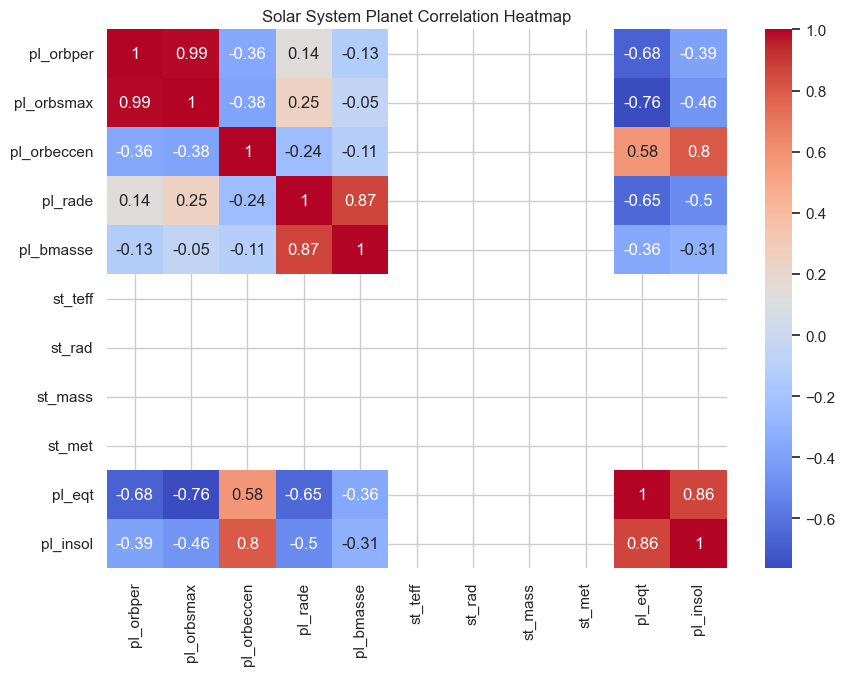

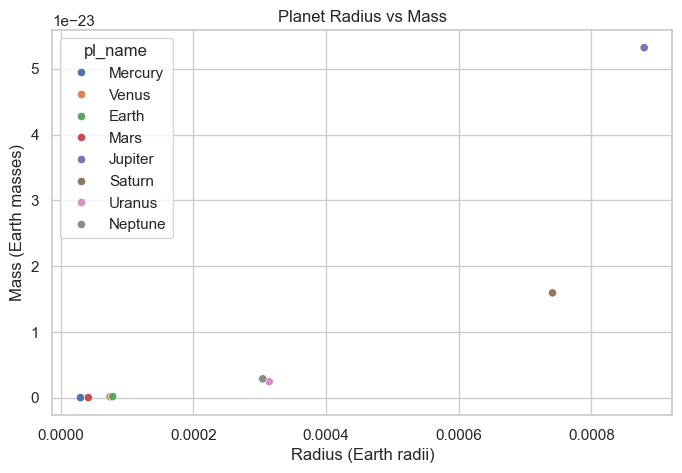

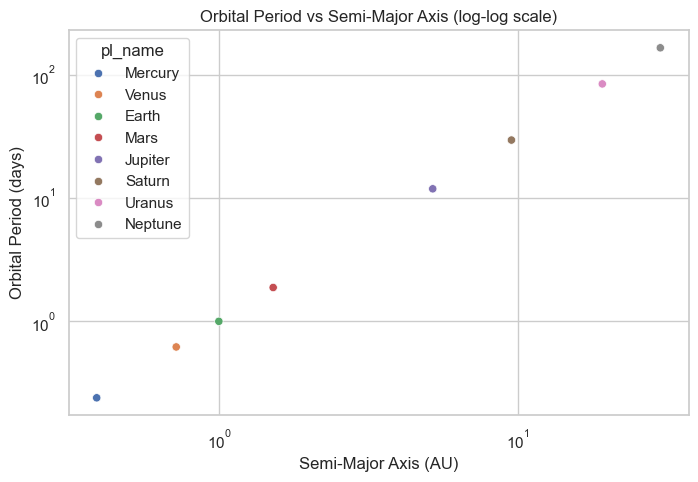

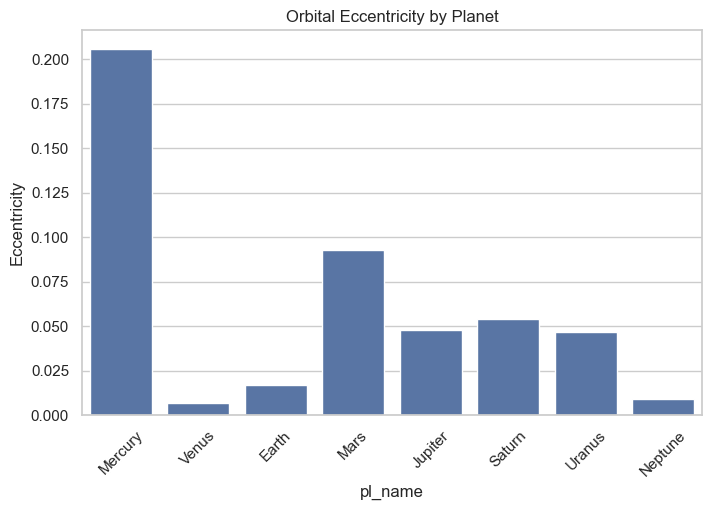

In [63]:
# --- 1. Overview ---
print("Shape:", solar_clean.shape)
print("\nColumns:\n", solar_clean.columns.tolist())
print("\nMissing Values:\n", solar_clean.isnull().sum())
print("\nDescriptive Stats:\n", solar_clean.describe())

# --- 2. Correlation Heatmap ---
plt.figure(figsize=(10, 7))
sns.heatmap(solar_clean.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Solar System Planet Correlation Heatmap")
plt.show()

# --- 3. Radius vs Mass ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=solar_clean, x='pl_rade', y='pl_bmasse', hue='pl_name')
plt.title("Planet Radius vs Mass")
plt.xlabel("Radius (Earth radii)")
plt.ylabel("Mass (Earth masses)")
plt.show()

# --- 4. Orbital Period vs Distance (Kepler's Law) ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=solar_clean, x='pl_orbsmax', y='pl_orbper', hue='pl_name')
plt.xscale("log")
plt.yscale("log")
plt.title("Orbital Period vs Semi-Major Axis (log-log scale)")
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (days)")
plt.show()

# --- 5. Eccentricity Plot ---
plt.figure(figsize=(8, 5))
sns.barplot(data=solar_clean, x='pl_name', y='pl_orbeccen')
plt.title("Orbital Eccentricity by Planet")
plt.xticks(rotation=45)
plt.ylabel("Eccentricity")
plt.show()

orbital period increases with distance
more eccentric planets tend to be smaller and closer in

In [64]:
exo_planets_clean.columns

Index(['pl_name', 'hostname', 'discoverymethod', 'disc_year', 'pl_orbper',
       'pl_orbsmax', 'pl_orbeccen', 'pl_rade', 'pl_bmasse', 'pl_eqt',
       'pl_insol', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'sy_dist'],
      dtype='object')

In [65]:
# Add 'origin' column
exo_planets_clean['origin'] = 'Exoplanet'
koi_clean['origin'] = 'KOI'
solar_clean['origin'] = 'Solar'

solar_clean.columns
# Ensure all have the same column order
columns = ['pl_name', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen',
                'pl_rade', 'pl_bmasse', 'st_teff', 'st_rad', 'st_mass',
                'st_met', 'pl_eqt','pl_insol', 'origin']

# Create missing columns in KOI
for col in columns:
    if col not in koi_clean.columns:
        koi_clean[col] = np.nan

exo_planets_clean = exo_planets_clean[columns]
koi_clean = koi_clean[columns]
solar_clean = solar_clean[columns]

# Merge datasets
combined_df = pd.concat([exo_planets_clean, koi_clean, solar_clean], ignore_index=True)

# Save to CSV (optional)
combined_df.to_csv("merged_planetary_data.csv", index=False)

print(combined_df['origin'].value_counts())
print(combined_df.shape)


C:\Users\bunho\AppData\Local\Temp\ipykernel_43284\588730115.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exo_planets_clean['origin'] = 'Exoplanet'


origin
Exoplanet    38509
KOI           4725
Solar            8
Name: count, dtype: int64
(43242, 13)
